# Projet — Classification de sons environnementaux (ESC-50)

Le dataset **ESC-50** (Environmental Sound Classification) contient **2 000 fichiers audio** répartis en **50 classes** de sons environnementaux (animaux, intérieur, extérieur, etc.).
Chaque fichier dure 5 secondes et est enregistré à 44 100 Hz.

Dans ce projet, on se concentre sur les **sons d'animaux** uniquement, soit **12 classes** sur les 50.

## Imports

On importe les bibliothèques nécessaires :
- **pandas** : chargement et manipulation des métadonnées (fichier CSV)
- **librosa** : chargement des fichiers audio et calcul de spectrogrammes
- **matplotlib** : visualisation des spectrogrammes
- **pathlib** : gestion des chemins de fichiers

In [24]:
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
from tqdm import tqdm

## Chargement des métadonnées

Le fichier `esc50.csv` décrit chaque échantillon audio avec les colonnes suivantes :
- **filename** : nom du fichier WAV
- **fold** : numéro de pli (1–5) utilisé pour la validation croisée
- **target** : identifiant numérique de la classe (0–49)
- **category** : nom de la classe (ex. `dog`, `frog`)
- **esc10** : booléen indiquant si l'échantillon fait partie du sous-ensemble ESC-10

On filtre ensuite le DataFrame pour ne conserver que les **12 classes animales**.

In [25]:
META_PATH = Path("meta/esc50.csv")
AUDIO_DIR = Path("audio")

ANIMAL_CLASSES = [
    "cat", "chirping_birds", "cow", "crickets", "crow",
    "dog", "frog", "hen", "insects", "pig", "rooster", "sheep"
]

df_full = pd.read_csv(META_PATH)
df = df_full[df_full["category"].isin(ANIMAL_CLASSES)].reset_index(drop=True)

print(f"Échantillons (total)   : {len(df_full)}")
print(f"Échantillons (animaux) : {len(df)}")
print(f"Nombre de classes      : {df['category'].nunique()}")
print(f"Classes                : {sorted(df['category'].unique())}")
df.head()

Échantillons (total)   : 2000
Échantillons (animaux) : 480
Nombre de classes      : 12
Classes                : ['cat', 'chirping_birds', 'cow', 'crickets', 'crow', 'dog', 'frog', 'hen', 'insects', 'pig', 'rooster', 'sheep']


,filename,fold,target,category,esc10,src_file,take
0,1-100032-A-0.wav,1,0,dog,True,100032,A
1,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A
2,1-103298-A-9.wav,1,9,crow,False,103298,A
3,1-110389-A-0.wav,1,0,dog,True,110389,A
4,1-121951-A-8.wav,1,8,sheep,False,121951,A


## Spectrogramme Mel

Pour traiter l'audio avec un réseau de neurones, on convertit chaque fichier sonore en une **image 2D** appelée spectrogramme Mel.

Le principe :
1. On applique une **transformée de Fourier à court terme** (STFT) pour découper le signal en fenêtres temporelles et obtenir le contenu fréquentiel à chaque instant.
2. On projette les fréquences sur l'**échelle Mel**, qui imite la perception humaine (les basses fréquences ont plus de résolution que les hautes).
3. On convertit les amplitudes en **décibels** (échelle logarithmique) pour que les valeurs soient plus stables à l'entraînement.

Résultat : une image de forme `(n_mels, T)` — `n_mels` bandes de fréquence en hauteur, `T` trames temporelles en largeur.

Paramètres utilisés :
- `sr=22050` : fréquence d'échantillonnage cible. Les fichiers ESC-50 sont nativement à **44 100 Hz** ; `librosa.load` les rééchantillonne automatiquement à 22 050 Hz. Ce choix divise par deux la taille des données sans perte significative d'information — la fréquence maximale représentée passe de 22 050 Hz à **11 025 Hz**, ce qui couvre largement les sons d'animaux (voix, chants, cris).
- `n_mels=128` : nombre de bandes Mel
- `hop_length=512` : décalage entre deux fenêtres consécutives (en échantillons). À `sr=22050`, cela correspond à une résolution temporelle d'environ **23 ms** par trame — soit 216 trames pour 5 secondes.

In [26]:
def load_spectrogram(filename, sr=22050, n_mels=128, hop_length=512):
    """Charge un fichier WAV et retourne son spectrogramme Mel en dB."""
    path = AUDIO_DIR / filename
    signal, _ = librosa.load(path, sr=sr)                          # signal 1D
    mel = librosa.feature.melspectrogram(                          # spectrogramme Mel
        y=signal, sr=sr, n_mels=n_mels, hop_length=hop_length
    )
    mel_db = librosa.power_to_db(mel, ref=mel.max())               # conversion en dB
    return mel_db, sr, hop_length

# Test sur un fichier
sample = df.iloc[0]
spec, sr, hop = load_spectrogram(sample["filename"])
print(f"Forme du spectrogramme : {spec.shape}  (n_mels × trames temporelles)")
print(f"Classe                 : {sample['category']}")

Forme du spectrogramme : (128, 216)  (n_mels × trames temporelles)
Classe                 : dog


## Visualisation

On visualise 9 exemples tirés aléatoirement pour comprendre à quoi ressemblent les données.
Chaque spectrogramme est affiché avec sa classe et le nom du fichier correspondant.

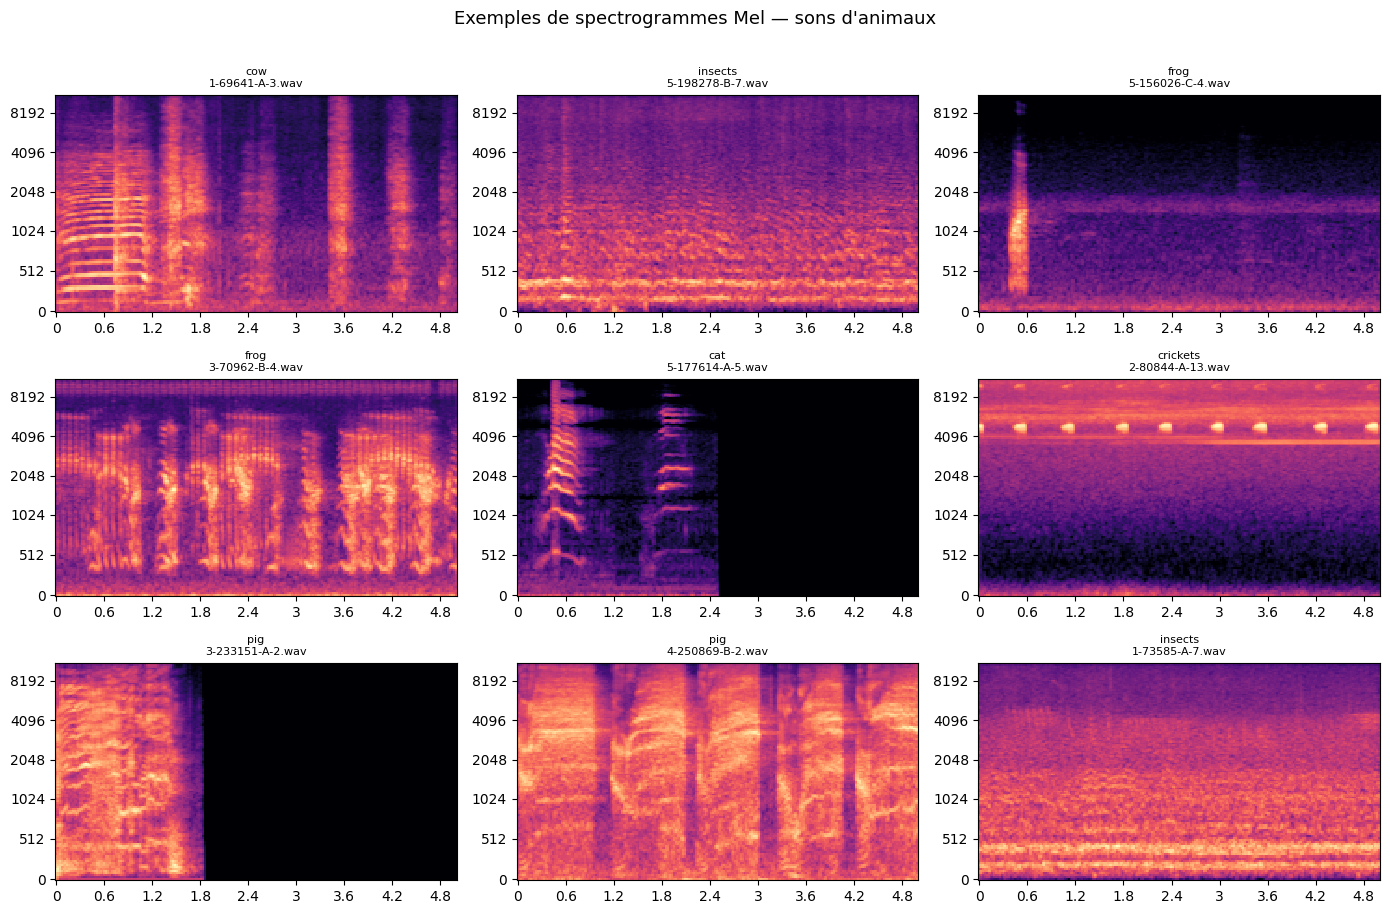

In [27]:
samples = df.sample(9, random_state=42)

fig, axes = plt.subplots(3, 3, figsize=(14, 9))

for ax, (_, row) in zip(axes.flat, samples.iterrows()):
    spec, sr, hop = load_spectrogram(row["filename"])
    librosa.display.specshow(
        spec, sr=sr, hop_length=hop,
        x_axis="time", y_axis="mel", ax=ax, cmap="magma"
    )
    ax.set_title(f"{row['category']}\n{row['filename']}", fontsize=8)
    ax.set_xlabel("")
    ax.set_ylabel("")

fig.suptitle("Exemples de spectrogrammes Mel — sons d'animaux", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Dataset et DataLoader

Pour entraîner un réseau PyTorch, on encapsule les données dans une classe `Dataset` qui gère le chargement à la volée de chaque échantillon. Le `DataLoader` s'appuie ensuite sur cette classe pour construire des **mini-batches** et les mélanger à chaque époque.

**Découpage train / test :** ESC-50 définit 5 folds de validation croisée. On utilise le **fold 5 comme ensemble de test** (96 échantillons) et les folds 1–4 comme entraînement (384 échantillons), conformément au protocole officiel du dataset.

La méthode `__getitem__` charge le spectrogramme et ajoute une dimension de canal pour obtenir un tenseur de forme `(1, 128, 216)` — équivalent à une image en niveaux de gris que le CNN peut traiter directement.

In [28]:
class ESC50Dataset(Dataset):
    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop=True)
        categories = sorted(self.df["category"].unique())
        self.class_to_idx = {c: i for i, c in enumerate(categories)}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        spec, _, _ = load_spectrogram(row["filename"])             # (128, 216)
        x = torch.tensor(spec, dtype=torch.float32).unsqueeze(0)  # (1, 128, 216)
        y = self.class_to_idx[row["category"]]
        return x, y


df_train = df[df["fold"] != 5]
df_test  = df[df["fold"] == 5]

train_dataset = ESC50Dataset(df_train)
test_dataset  = ESC50Dataset(df_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

x_batch, y_batch = next(iter(train_loader))
print(f"Train : {len(train_dataset)} échantillons  |  Test : {len(test_dataset)} échantillons")
print(f"Forme d'un batch : {x_batch.shape}  →  labels : {y_batch.shape}")

Train : 384 échantillons  |  Test : 96 échantillons
Forme d'un batch : torch.Size([32, 1, 128, 216])  →  labels : torch.Size([32])


## Création du CNN

Les spectrogrammes Mel sont des images 2D de taille `(1, 128, 216)` — on peut donc y appliquer exactement les mêmes convolutions que sur des images classiques.

L'architecture utilise **3 blocs convolutifs** successifs, chacun composé de :
- `Conv2d` : détecte des motifs locaux (bords, textures fréquentielles)
- `BatchNorm2d` : normalise les activations pour stabiliser l'entraînement
- `ReLU` : introduit la non-linéarité
- `MaxPool2d(2, 2)` : divise la résolution spatiale par 2

Après les convolutions, un **classifieur entièrement connecté** produit un score par classe.

```
Entrée : (1, 128, 216)
  → conv_block1 : Conv2d(1→32)   + BN + ReLU + MaxPool  →  (32,  64, 108)
  → conv_block2 : Conv2d(32→64)  + BN + ReLU + MaxPool  →  (64,  32,  54)
  → conv_block3 : Conv2d(64→128) + BN + ReLU + MaxPool  → (128,  16,  27)
  → Flatten → Linear(55296→256) → ReLU → Dropout(0.3) → Linear(256→12)
```

In [29]:
class CNN(nn.Module):
    def __init__(self, n_classes=12):
        super().__init__()
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        self.conv_block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 27, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, n_classes),
        )

    def forward(self, x):
        x = self.conv_block1(x)   # (B,  32,  64, 108)
        x = self.conv_block2(x)   # (B,  64,  32,  54)
        x = self.conv_block3(x)   # (B, 128,  16,  27)
        x = self.classifier(x)    # (B,  12)
        return x


cnn = CNN()

n_params = sum(p.numel() for p in cnn.parameters() if p.requires_grad)
print(f"Paramètres entraînables : {n_params:,}")

x_dummy = torch.randn(1, 1, 128, 216)
out = cnn(x_dummy)
print(f"Forward pass : entrée {tuple(x_dummy.shape)} → sortie {tuple(out.shape)}")

Paramètres entraînables : 14,252,236
Forward pass : entrée (1, 1, 128, 216) → sortie (1, 12)


## Entraînement

L'entraînement repose sur les mêmes éléments que dans les ateliers précédents :

- **`CrossEntropyLoss`** : mesure l'écart entre les scores prédits et la vraie classe. C'est la fonction de perte standard pour la classification multi-classes.
- **`AdamW`** (lr=1e-3) : optimiseur adaptatif qui met à jour les poids à chaque batch en suivant le gradient.
- **`ReduceLROnPlateau`** : réduit le taux d'apprentissage d'un facteur 0.5 si la loss de validation ne s'améliore pas pendant 3 époques consécutives.
- **Early stopping** (patience=5) : arrête l'entraînement si aucune amélioration n'est constatée pendant 5 époques, et restaure les meilleurs poids.
- **`SummaryWriter`** : enregistre les métriques pour TensorBoard (`tensorboard --logdir runs/`).

In [30]:
def train_loop(dataloader, model, loss_fn, optimizer, writer, epoch):
    model.train()
    pbar = tqdm(dataloader, desc="Train")
    for batch, (x, y_true) in enumerate(pbar):
        y_pred = model(x)
        loss = loss_fn(y_pred, y_true)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        pbar.set_postfix(loss=f"{loss.item():.4f}")
        writer.add_scalar("Loss/train", loss.item(), epoch * len(dataloader) + batch)


def test_loop(dataloader, model, loss_fn, writer, epoch):
    model.eval()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0

    with torch.no_grad():
        for x, y_true in tqdm(dataloader, desc="Test "):
            y_pred = model(x)
            test_loss += loss_fn(y_pred, y_true).item()
            correct += (y_pred.argmax(1) == y_true).type(torch.float).sum().item()

    test_loss /= num_batches
    correct /= size
    print(f"Accuracy : {100 * correct:.1f}%  |  Avg loss : {test_loss:.6f}")

    writer.add_scalar("Loss/test", test_loss, epoch)
    writer.add_scalar("Accuracy/test", 100 * correct, epoch)

    return test_loss

In [31]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(cnn.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)
writer    = SummaryWriter("runs/cnn_esc50")

In [32]:
epochs     = 30
es_patience = 5

best_loss   = float("inf")
best_weights = None
epochs_without_improvement = 0

for t in range(epochs):
    print(f"Epoch : {t+1}  |  lr = {optimizer.param_groups[0]['lr']:.2e}")
    train_loop(train_loader, cnn, criterion, optimizer, writer, t)
    val_loss = test_loop(test_loader, cnn, criterion, writer, t)

    scheduler.step(val_loss)

    if val_loss < best_loss:
        best_loss = val_loss
        best_weights = {k: v.cpu().clone() for k, v in cnn.state_dict().items()}
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
        print(f"  (pas d'amélioration depuis {epochs_without_improvement} époque(s))")
        if epochs_without_improvement >= es_patience:
            print(f"Early stopping déclenché à l'époque {t+1}.")
            break

cnn.load_state_dict(best_weights)
writer.close()
print("Entraînement terminé.")

Epoch : 1  |  lr = 1.00e-03


Test : 100%|██████████| 3/3 [00:04<00:00,  1.37s/it]


Accuracy : 12.5%  |  Avg loss : 8.118934
Epoch : 2  |  lr = 1.00e-03


Test : 100%|██████████| 3/3 [00:03<00:00,  1.23s/it]


Accuracy : 27.1%  |  Avg loss : 2.128879
Epoch : 3  |  lr = 1.00e-03


...

Accuracy : 64.6%  |  Avg loss : 1.302170
  (pas d'amélioration depuis 3 époque(s))
Epoch : 19  |  lr = 1.00e-03


Test : 100%|██████████| 3/3 [00:04<00:00,  1.57s/it]


Accuracy : 59.4%  |  Avg loss : 1.281895
  (pas d'amélioration depuis 4 époque(s))
Epoch : 20  |  lr = 5.00e-04


Test : 100%|██████████| 3/3 [00:04<00:00,  1.46s/it]

Accuracy : 60.4%  |  Avg loss : 1.348227
  (pas d'amélioration depuis 5 époque(s))
Early stopping déclenché à l'époque 20.
Entraînement terminé.
